In [1]:
import numpy as np
import cv2
import os
from skimage import io
import os.path as osp
import random
from sklearn.svm import SVC
import joblib
import matplotlib as plt
from sklearn import metrics

def hog_descriptor(image):

    if (image.max()-image.min()) != 0:
        image = (image - image.min()) / (image.max() - image.min())
        image *= 255               #这两行是对图像做归一化
        image = image.astype(np.uint8)
    hog = cv2.HOGDescriptor((64, 128), (16, 16), (8, 8), (8, 8), 9)  
    hog_feature = hog.compute(image)    #提取HOG特征

    return hog_feature


In [16]:
#导入图像
poslist = os.listdir('D:/学习/专业课/cv/INRIADATA/normalized_images/train/pos')
neglist = os.listdir('D:/学习/专业课/cv/INRIADATA/normalized_images/train/neg')
testlistp = os.listdir('D:/学习/专业课/cv/INRIADATA/original_images/test/pos')
testlistn = os.listdir('D:/学习/专业课/cv/INRIADATA/original_images/test/neg')


In [5]:
hog_list = []
label_list = []
for i in range(len(poslist)):
    posimg = io.imread(osp.join('D:/学习/专业课/cv/INRIADATA/normalized_images/train/pos',poslist[i]))
    posimg = cv2.cvtColor(posimg,cv2.COLOR_RGBA2BGR)
    #所用图像已经经过标准化
    posimg = cv2.resize(posimg, (64, 128), interpolation=cv2.INTER_NEAREST)
    pos_hog = hog_descriptor(posimg)
    hog_list.append(pos_hog)
    label_list.append(1)
for i in range(len(neglist)):
    negimg = io.imread(osp.join('D:/学习/专业课/cv/INRIADATA/normalized_images/train/neg',neglist[i]))
    negimg = cv2.cvtColor(negimg, cv2.COLOR_RGBA2BGR)

    #在每张negimg图像中截取10张标准大小的图片作为负样本
    for j in range(10):
        y = int(random.random() * (negimg.shape[0] - 128))
        x = int(random.random() * (negimg.shape[1] - 64))
        negimgs = negimg[y:y + 128, x:x + 64]
        negimgs = cv2.resize(negimgs, (64, 128), interpolation=cv2.INTER_NEAREST)
        neg_hog = hog_descriptor(negimgs)
        hog_list.append(neg_hog)
        label_list.append(0)


In [6]:
#训练SVM
hog_list = np.array(hog_list)
label_list = np.array(label_list)
clf = SVC(C=1.0, gamma='auto', kernel='rbf', probability=True)
clf.fit(hog_list.squeeze(), label_list.squeeze())
joblib.dump(clf, "D:/学习/专业课/cv/行人检测/trained_svm.m")#保存训练好的模型


['D:/学习/专业课/cv/行人检测/trained_svm.m']

In [17]:
test_hog = []
test_label = []
for i in range(len(testlistp)):
    posimg = io.imread(osp.join('D:/学习/专业课/cv/INRIADATA/original_images/test/pos',testlistp[i]))
    posimg = cv2.cvtColor(posimg,cv2.COLOR_RGBA2BGR)
    #所用图像已经经过标准化
    posimg = cv2.resize(posimg, (64, 128), interpolation=cv2.INTER_NEAREST)
    pos_hog = hog_descriptor(posimg)
    test_hog.append(pos_hog)
    test_label.append(1)
for i in range(len(testlistn)):
    negimg = io.imread(osp.join('D:/学习/专业课/cv/INRIADATA/original_images/test/neg',testlistn[i]))
    negimg = cv2.cvtColor(negimg, cv2.COLOR_RGBA2BGR)

    #在每张negimg图像中截取10张标准大小的图片作为负样本
    for j in range(10):
        y = int(random.random() * (negimg.shape[0] - 128))
        x = int(random.random() * (negimg.shape[1] - 64))
        negimgs = negimg[y:y + 128, x:x + 64]
        negimgs = cv2.resize(negimgs, (64, 128), interpolation=cv2.INTER_NEAREST)
        neg_hog = hog_descriptor(negimgs)
        test_hog.append(neg_hog)
        test_label.append(0)

0.9071552305616875


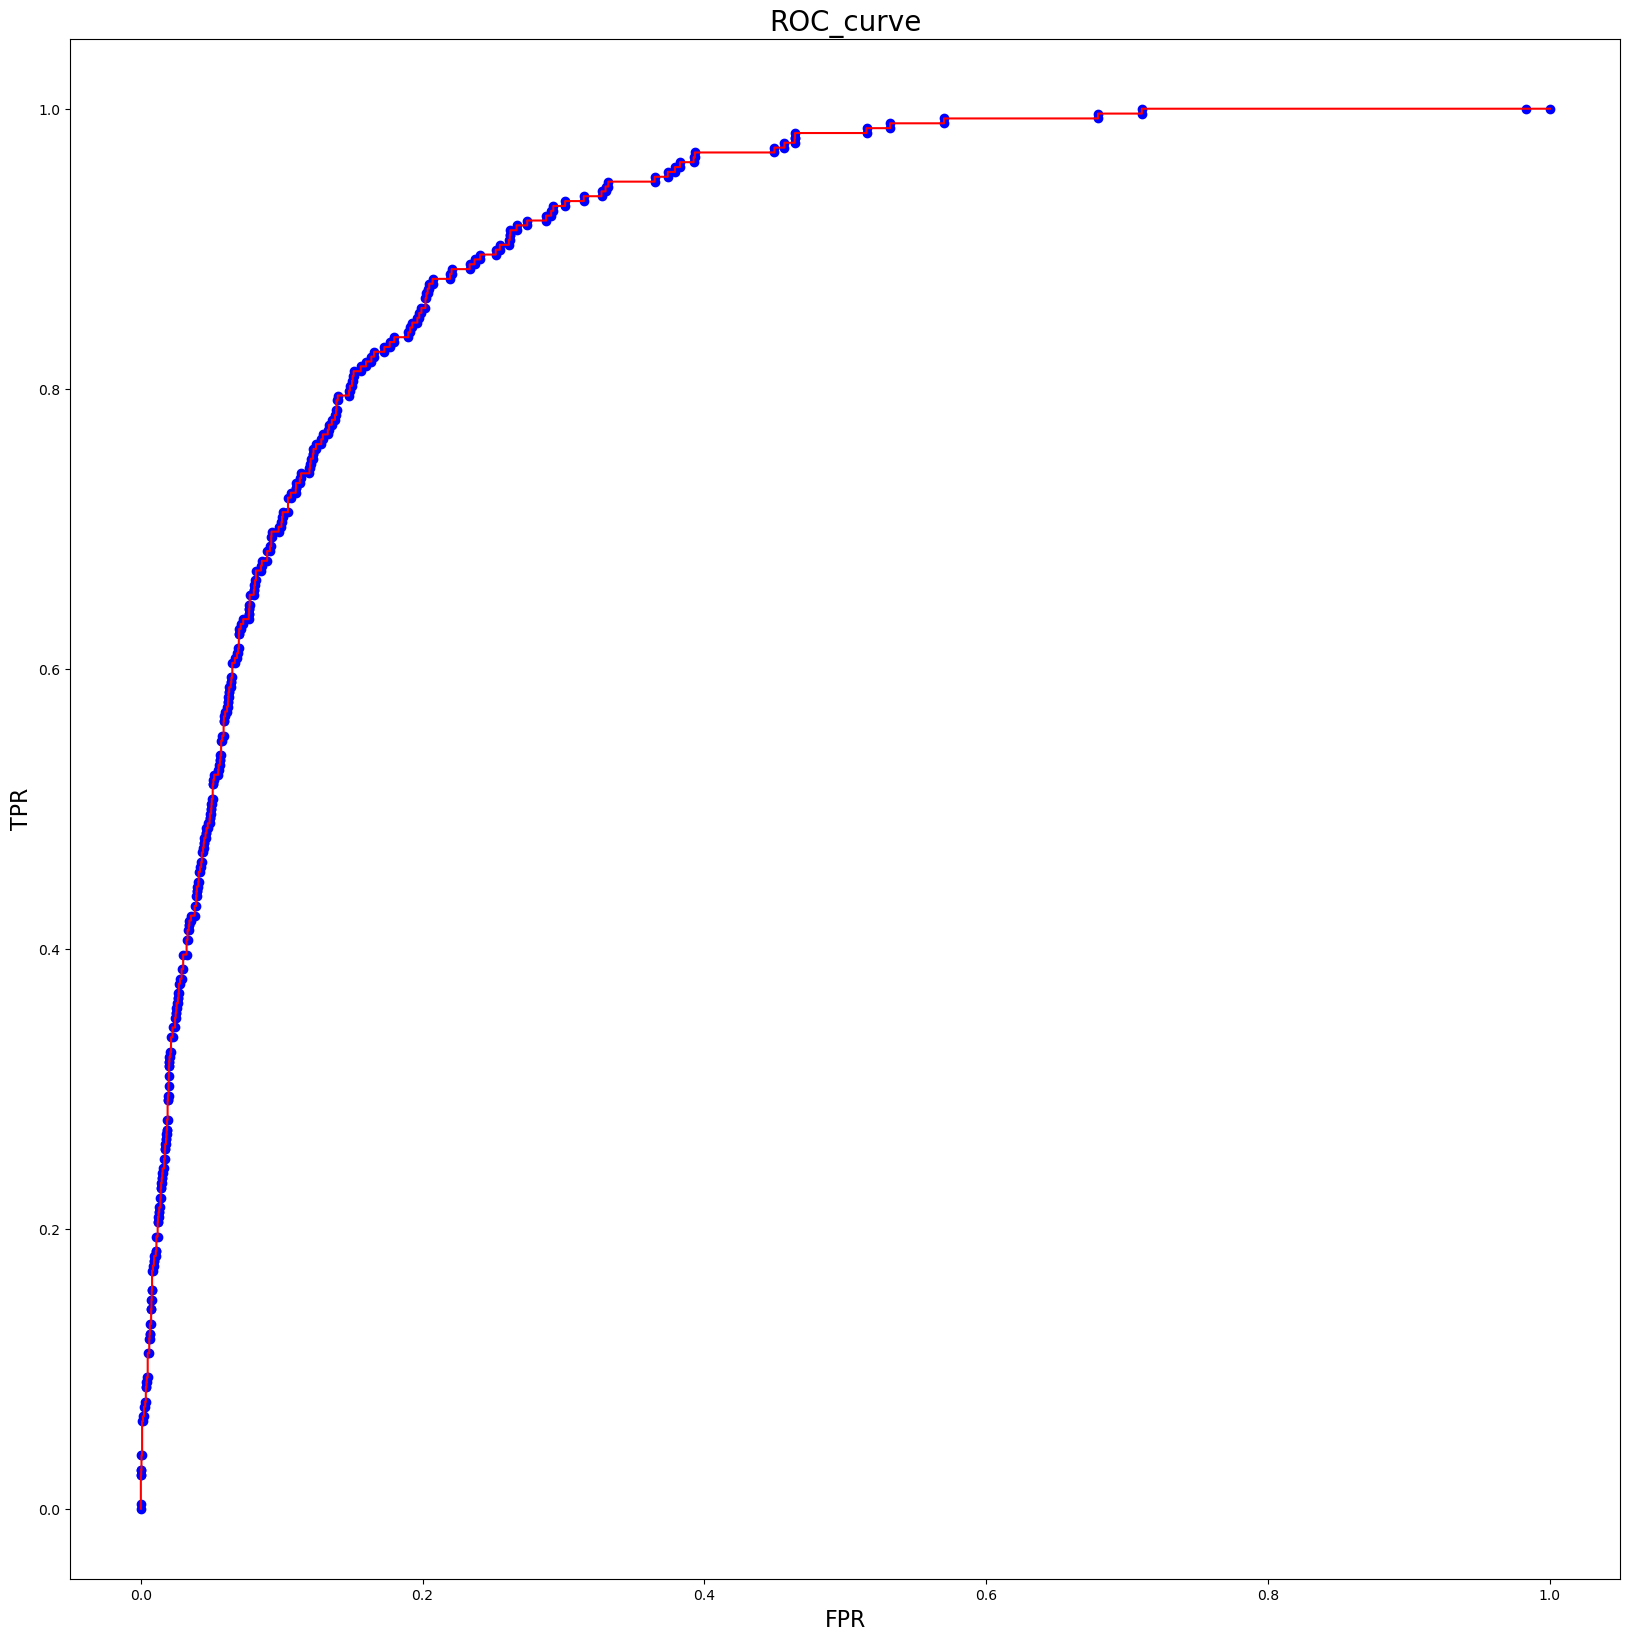

In [19]:
import matplotlib.pyplot as plt
clf = joblib.load("D:/学习/专业课/cv/行人检测/trained_svm.m")
test_hog = np.array(test_hog)
test_label = np.array(test_label)

#对训练集进行预测并绘制PR、ROC曲线计算AUC值
prob = clf.predict_proba(test_hog.squeeze())[:, 1]

precision, recall, thresholds_1 = metrics.precision_recall_curve(test_label.squeeze(), prob)

fpr, tpr, thresholds_2 = metrics.roc_curve(test_label.squeeze(), prob, pos_label=1)

plt.figure(figsize=(20, 20), dpi=100)
plt.plot(fpr, tpr, c='red')
plt.scatter(fpr, tpr, c='blue')
plt.xlabel("FPR", fontdict={'size': 16})
plt.ylabel("TPR", fontdict={'size': 16})
plt.title("ROC_curve", fontdict={'size': 20})
plt.savefig('D:/学习/专业课/cv/ROC.png', dpi=300)

AUC=metrics.roc_auc_score(test_label.squeeze(), prob)
print(AUC)
